## 0. Подключение Google Drive (общая папка для всех 6 ноутбуков)
Запусти эту ячейку первой. Она монтирует Drive и переключает рабочую папку в `/content/drive/MyDrive/happiness_formula`, чтобы все ноутбуки видели файлы друг друга через `artifacts/`, даже если ты запускаешь их в разных сессиях.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_PATH = '/content/drive/MyDrive/happiness_formula'  # можешь поменять имя папки
os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH)

print('Текущая рабочая папка:', os.getcwd())

data_json = Path(PROJECT_PATH) / 'data.json'
if data_json.exists():
    print('data.json найден')
else:
    print('data.json НЕ найден — положи его в', PROJECT_PATH, '(нужен только для ноутбука 01)')

artifacts_dir = Path(PROJECT_PATH) / 'artifacts'
if artifacts_dir.exists():
    existing = sorted(p.name for p in artifacts_dir.iterdir())
    print(f'В artifacts/ уже есть {len(existing)} файлов/папок:')
    for name in existing:
        print(' -', name)
else:
    print('Папка artifacts/ пока пустая, появится после первого запуска')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Текущая рабочая папка: /content/drive/MyDrive/happiness_formula
data.json найден
В artifacts/ уже есть 4 файлов/папок:
 - 01_eda.png
 - 01_sentiment_sample.csv
 - 01_vk_posts.csv
 - 01_vk_users.csv


# 02 — Baseline: TF-IDF + Logistic Regression

Раздел 5. Baseline строится на том же сбалансированном датасете, который был сохранён в файле `01`.

Артефакты на выходе:
- `artifacts/02_sentiment_split.joblib` — единое train/test-разбиение для всех следующих моделей;
- `artifacts/02_tfidf_vectorizer.joblib`;
- `artifacts/02_logreg_model.joblib`;
- `artifacts/02_logreg_metrics.json`;
- `artifacts/02_logreg_predictions.csv`.

### Проверка зависимостей

In [8]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'datasets': 'datasets',
    'joblib': 'joblib',
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Устанавливаются отсутствующие зависимости:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Все зависимости доступны.')

Все зависимости доступны.


## Импорты и конфигурация

In [9]:
import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_NAMES = ['Негативный', 'Позитивный', 'Нейтральный']
LABEL2NAME = {0: 'Негативный', 1: 'Позитивный', 2: 'Нейтральный'}
ID2LABEL = {0: 'NEGATIVE', 1: 'POSITIVE', 2: 'NEUTRAL'}
LABEL2ID = {'NEGATIVE': 0, 'POSITIVE': 1, 'NEUTRAL': 2}

TOXIC_KEYWORDS = [
    'депрессия', 'грусть', 'боль', 'слезы', 'слёзы', 'одиночество',
    'апатия', 'ненависть', 'суицид', 'смерть', 'безысходность',
]

sns.set_theme(style='whitegrid', palette='Set2')


def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)
print(f'Рабочая папка: {PROJECT_DIR}')
print(f'Папка артефактов: {ARTIFACT_DIR}')

import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split

Рабочая папка: /content/drive/MyDrive/happiness_formula
Папка артефактов: /content/drive/MyDrive/happiness_formula/artifacts


In [10]:
def clean_text(text: str) -> str:
    """Очистка текста для TF-IDF и xLSTM. Для RuBERT используется исходный текст."""
    text = '' if pd.isna(text) else str(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^а-яёА-ЯЁa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

## 5. Baseline: TF-IDF + Logistic Regression

In [11]:
sentiment_path = ARTIFACT_DIR / '01_sentiment_sample.csv'
if not sentiment_path.exists():
    raise FileNotFoundError('Не найден artifacts/01_sentiment_sample.csv. Сначала запустите файл 01.')

df_sample = pd.read_csv(sentiment_path)
if 'text_clean' not in df_sample.columns:
    df_sample['text_clean'] = df_sample['text'].apply(clean_text)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_sample['text'].astype(str).tolist(),
    df_sample['label'].astype(int).tolist(),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_sample['label'].astype(int).tolist(),
)

X_train_clean = [clean_text(text) for text in X_train_raw]
X_test_clean = [clean_text(text) for text in X_test_raw]

split = {
    'X_train_raw': X_train_raw,
    'X_test_raw': X_test_raw,
    'X_train_clean': X_train_clean,
    'X_test_clean': X_test_clean,
    'y_train': y_train,
    'y_test': y_test,
}
joblib.dump(split, ARTIFACT_DIR / '02_sentiment_split.joblib')

print(f'Train: {len(X_train_raw)} | Test: {len(X_test_raw)}')

Train: 6000 | Test: 1500


TF-IDF + Logistic Regression
TF-IDF матрица: (6000, 20000)
              precision    recall  f1-score   support

  Негативный       0.52      0.52      0.52       500
  Позитивный       0.72      0.70      0.71       500
 Нейтральный       0.62      0.64      0.63       500

    accuracy                           0.62      1500
   macro avg       0.62      0.62      0.62      1500
weighted avg       0.62      0.62      0.62      1500



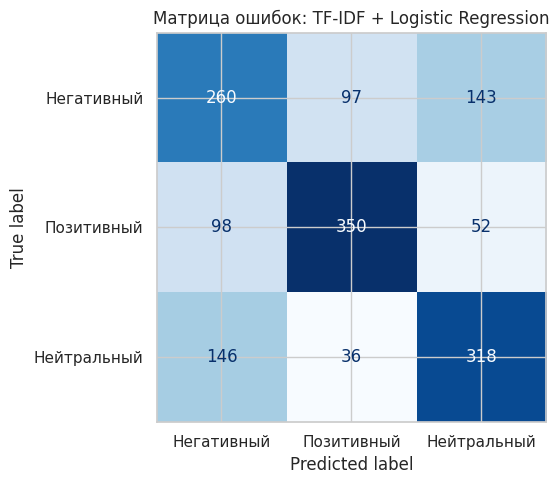

In [12]:
vectorizer = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
)
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)

logreg = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=None,
)
logreg.fit(X_train_vec, y_train)
logreg_preds = logreg.predict(X_test_vec)
logreg_f1 = f1_score(y_test, logreg_preds, average='weighted')
logreg_accuracy = accuracy_score(y_test, logreg_preds)

print('TF-IDF + Logistic Regression')
print(f'TF-IDF матрица: {X_train_vec.shape}')
print(classification_report(y_test, logreg_preds, target_names=TARGET_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, logreg_preds)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Матрица ошибок: TF-IDF + Logistic Regression')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / '02_cm_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
metrics = {
    'model': 'TF-IDF + Logistic Regression',
    'type': 'Classical ML',
    'f1_weighted': float(logreg_f1),
    'accuracy': float(logreg_accuracy),
    'n_train': len(X_train_raw),
    'n_test': len(X_test_raw),
}

predictions_df = pd.DataFrame({
    'text': X_test_raw,
    'label_true': y_test,
    'label_pred': logreg_preds,
})
predictions_df['label_true_name'] = predictions_df['label_true'].map(LABEL2NAME)
predictions_df['label_pred_name'] = predictions_df['label_pred'].map(LABEL2NAME)

joblib.dump(vectorizer, ARTIFACT_DIR / '02_tfidf_vectorizer.joblib')
joblib.dump(logreg, ARTIFACT_DIR / '02_logreg_model.joblib')
with open(ARTIFACT_DIR / '02_logreg_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(metrics, file, ensure_ascii=False, indent=2)
predictions_df.to_csv(ARTIFACT_DIR / '02_logreg_predictions.csv', index=False, encoding='utf-8-sig')

print('Метрики baseline:')
print(json.dumps(metrics, ensure_ascii=False, indent=2))

Метрики baseline:
{
  "model": "TF-IDF + Logistic Regression",
  "type": "Classical ML",
  "f1_weighted": 0.6192907300226874,
  "accuracy": 0.6186666666666667,
  "n_train": 6000,
  "n_test": 1500
}
